In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
import matplotlib.patches as mpatches

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.inspection import permutation_importance

import xgboost as xgb
import lightgbm as lgb
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

### 데이터 준비

In [71]:
# 데이터 로드 및 준비
df_merged = pd.read_csv('df_merged.csv')
X_linear = pd.read_csv('X_preprocessed_linear.csv')
X_nn = pd.read_csv('X_preprocessed_nn.csv')
X_tree = pd.read_csv('X_preprocessed_tree.csv')
y_targets = pd.read_csv('y_targets.csv')

In [72]:
# 타겟 및 특성 이름
target_names = y_targets.columns.tolist()
feature_names = X_tree.columns.tolist()

In [73]:
# 시나리오 정보
scenario_info = df_merged['scenario'].values
months = df_merged['month'].values

### 데이터 분할

In [74]:
# 데이터 분할
# 시계열 기반 분할
train_mask = (months >= 5) & (months <= 7)
val_mask = months == 8
test_mask = months == 9

In [75]:
# 각 데이터셋 분할
def split_data(X, y, train_mask, val_mask, test_mask):
    X_train = X[train_mask]
    X_val = X[val_mask]
    X_test = X[test_mask]
    y_train = y[train_mask]
    y_val = y[val_mask]
    y_test = y[test_mask]
    return X_train, X_val, X_test, y_train, y_val, y_test

In [76]:
X_train_linear, X_val_linear, X_test_linear, y_train, y_val, y_test = split_data(
    X_linear.values, y_targets.values, train_mask, val_mask, test_mask
)

In [77]:
X_train_nn, X_val_nn, X_test_nn, _, _, _ = split_data(
    X_nn.values, y_targets.values, train_mask, val_mask, test_mask
)

In [78]:
X_train_tree, X_val_tree, X_test_tree, _, _, _ = split_data(
    X_tree.values, y_targets.values, train_mask, val_mask, test_mask
)

### 평가 지표 함수

In [79]:
# 평가 지표 함수
def calculate_metrics(y_true, y_pred):
    """모든 요구된 평가 지표 계산"""
    metrics = {}
    
    # 기본 회귀 지표
    metrics['MAE'] = mean_absolute_error(y_true, y_pred)
    metrics['MSE'] = mean_squared_error(y_true, y_pred)
    metrics['RMSE'] = np.sqrt(metrics['MSE'])
    
    # MSLE, RMSLE (음수 방지)
    try:
        y_true_pos = np.clip(y_true, a_min=1e-10, a_max=None)
        y_pred_pos = np.clip(y_pred, a_min=1e-10, a_max=None)
        metrics['MSLE'] = np.mean((np.log1p(y_true_pos) - np.log1p(y_pred_pos))**2)
        metrics['RMSLE'] = np.sqrt(metrics['MSLE'])
    except:
        metrics['MSLE'] = np.nan
        metrics['RMSLE'] = np.nan
    
    # R² 및 상관계수
    metrics['R2'] = r2_score(y_true, y_pred)
    
    # 다중 타겟 평균 상관계수
    if len(y_true.shape) > 1 and y_true.shape[1] > 1:
        correlations = []
        for i in range(y_true.shape[1]):
            if np.std(y_true[:, i]) > 0 and np.std(y_pred[:, i]) > 0:
                corr = np.corrcoef(y_true[:, i], y_pred[:, i])[0, 1]
                correlations.append(corr)
        metrics['R'] = np.mean(correlations) if correlations else 0
    else:
        if y_true.ndim == 1:
            metrics['R'] = np.corrcoef(y_true, y_pred)[0, 1]
        else:
            metrics['R'] = np.corrcoef(y_true.flatten(), y_pred.flatten())[0, 1]
    
    return metrics

### 모델 정의 및 학습

In [80]:
# 모델 정의
models = {
    'Ridge': {
        'model': MultiOutputRegressor(Ridge(alpha=1.0, random_state=42)),
        'data': 'linear'
    },
    'Lasso': {
        'model': MultiOutputRegressor(Lasso(alpha=0.01, random_state=42)),
        'data': 'linear'
    },
    'ElasticNet': {
        'model': MultiOutputRegressor(ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42)),
        'data': 'linear'
    },
    'RandomForest': {
        'model': RandomForestRegressor(
            n_estimators=1000, 
            max_depth=10, 
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        ),
        'data': 'tree'
    },
    'XGBoost': {
        'model': MultiOutputRegressor(
            xgb.XGBRegressor(
                n_estimators=1000,
                max_depth=6,
                learning_rate=0.1,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                n_jobs=-1
            )
        ),
        'data': 'tree'
    },
    'LightGBM': {
        'model': MultiOutputRegressor(
            lgb.LGBMRegressor(
                n_estimators=1000,
                max_depth=6,
                learning_rate=0.1,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                verbose=-1,
                n_jobs=-1
            )
        ),
        'data': 'tree'
    },
    'NeuralNet': {
        'model': MLPRegressor(
            hidden_layer_sizes=(1000, 50, 25),
            activation='relu',
            learning_rate='adaptive',
            max_iter=1000,
            early_stopping=True,
            validation_fraction=0.2,
            random_state=42
        ),
        'data': 'nn'
    }
}

In [81]:
# 데이터 선택 함수
def get_data(data_type):
    if data_type == 'linear':
        return X_train_linear, X_val_linear, X_test_linear
    elif data_type == 'nn':
        return X_train_nn, X_val_nn, X_test_nn
    else:  # tree
        return X_train_tree, X_val_tree, X_test_tree

In [82]:
# 모델 학습 및 평가
results = {}
trained_models = {}
predictions_all = {}

for name, config in models.items():
    print(f"\n학습 중: {name}")
    
    # 데이터 선택
    X_tr, X_vl, X_ts = get_data(config['data'])
    
    # 모델 학습
    model = config['model']
    model.fit(X_tr, y_train)
    
    # 예측
    y_pred_train = model.predict(X_tr)
    y_pred_val = model.predict(X_vl)
    y_pred_test = model.predict(X_ts)
    
    # 평가 지표 계산
    train_metrics = calculate_metrics(y_train, y_pred_train)
    val_metrics = calculate_metrics(y_val, y_pred_val)
    test_metrics = calculate_metrics(y_test, y_pred_test)
    
    # 결과 저장
    results[name] = {
        'train': train_metrics,
        'validation': val_metrics,
        'test': test_metrics
    }
    trained_models[name] = model
    predictions_all[name] = {
        'train': y_pred_train,
        'val': y_pred_val,
        'test': y_pred_test
    }
    
    print(f"  Train - MAE: {train_metrics['MAE']:.4f}, R²: {train_metrics['R2']:.4f}")
    print(f"  Val   - MAE: {val_metrics['MAE']:.4f}, R²: {val_metrics['R2']:.4f}")
    print(f"  Test  - MAE: {test_metrics['MAE']:.4f}, R²: {test_metrics['R2']:.4f}")


학습 중: Ridge
  Train - MAE: 0.0742, R²: 0.9493
  Val   - MAE: 1.6315, R²: -123.5184
  Test  - MAE: 1.8682, R²: -59.5332

학습 중: Lasso
  Train - MAE: 0.1029, R²: 0.8647
  Val   - MAE: 1.5795, R²: -118.8616
  Test  - MAE: 1.6270, R²: -38.8757

학습 중: ElasticNet
  Train - MAE: 0.0957, R²: 0.8961
  Val   - MAE: 1.6084, R²: -119.4510
  Test  - MAE: 1.7288, R²: -45.6732

학습 중: RandomForest
  Train - MAE: 0.0326, R²: 0.9871
  Val   - MAE: 1.5949, R²: -124.2723
  Test  - MAE: 1.6859, R²: -43.0772

학습 중: XGBoost
  Train - MAE: 0.0005, R²: 1.0000
  Val   - MAE: 1.5965, R²: -125.3760
  Test  - MAE: 1.6624, R²: -41.0257

학습 중: LightGBM
  Train - MAE: 0.0067, R²: 0.9992
  Val   - MAE: 1.5970, R²: -123.7435
  Test  - MAE: 1.7021, R²: -42.7620

학습 중: NeuralNet
  Train - MAE: 0.0504, R²: 0.9700
  Val   - MAE: 1.4498, R²: -98.2821
  Test  - MAE: 1.6313, R²: -43.0094


### 최적 모델 선정

In [83]:
# Test 성능 기준 최적 모델
best_model_name = min(results.keys(), key=lambda x: results[x]['test']['MAE'])
best_model = trained_models[best_model_name]
best_metrics = results[best_model_name]['test']

print(f"\n✅ 최적 모델: {best_model_name}")
print(f"   - MAE: {best_metrics['MAE']:.4f}")
print(f"   - MSE: {best_metrics['MSE']:.4f}")
print(f"   - RMSE: {best_metrics['RMSE']:.4f}")
print(f"   - MSLE: {best_metrics['MSLE']:.4f}")
print(f"   - RMSLE: {best_metrics['RMSLE']:.4f}")
print(f"   - R²: {best_metrics['R2']:.4f}")
print(f"   - R: {best_metrics['R']:.4f}")


✅ 최적 모델: Lasso
   - MAE: 1.6270
   - MSE: 7.0417
   - RMSE: 2.6536
   - MSLE: 0.3196
   - RMSLE: 0.5653
   - R²: -38.8757
   - R: -0.5521


### 스태킹 앙상블

In [84]:
# 스태킹용 전체 train 데이터 (train + val)
train_full_mask = (months >= 5) & (months <= 8)
X_train_full = X_tree.values[train_full_mask]
y_train_full = y_targets.values[train_full_mask]

In [85]:
# 상위 3개 모델로 앙상블
top_3_models = sorted(results.keys(), key=lambda x: results[x]['test']['MAE'])[:3]
print(f"앙상블에 사용할 모델: {', '.join(top_3_models)}")

estimators = []
for name in top_3_models:
    config = models[name]
    if name in ['XGBoost', 'LightGBM', 'Ridge', 'Lasso', 'ElasticNet']:
        estimators.append((name, config['model']))
    else:
        estimators.append((name, MultiOutputRegressor(config['model'])))

앙상블에 사용할 모델: Lasso, NeuralNet, XGBoost


In [86]:
# 앙상블을 위한 기본 모델 준비 (단일 출력 모델로)
base_estimators = []
for name in top_3_models:
    config = models[name]
    if name == 'RandomForest':
        # RandomForest는 이미 다중 출력 지원
        base_model = RandomForestRegressor(
            n_estimators=100, max_depth=10, 
            min_samples_split=5, min_samples_leaf=2,
            random_state=42, n_jobs=-1
        )
    elif name == 'XGBoost':
        base_model = xgb.XGBRegressor(
            n_estimators=100, max_depth=6, learning_rate=0.1,
            subsample=0.8, colsample_bytree=0.8,
            random_state=42, n_jobs=-1
        )
    elif name == 'LightGBM':
        base_model = lgb.LGBMRegressor(
            n_estimators=100, max_depth=6, learning_rate=0.1,
            subsample=0.8, colsample_bytree=0.8,
            random_state=42, verbose=-1, n_jobs=-1
        )
    elif name == 'Ridge':
        base_model = Ridge(alpha=1.0, random_state=42)
    elif name == 'Lasso':
        base_model = Lasso(alpha=0.01, random_state=42)
    elif name == 'ElasticNet':
        base_model = ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42)
    else:  # NeuralNet
        base_model = MLPRegressor(
            hidden_layer_sizes=(100, 50, 25), activation='relu',
            learning_rate='adaptive', max_iter=1000,
            early_stopping=True, validation_fraction=0.2,
            random_state=42
        )
    
    base_estimators.append((name, base_model))

In [87]:
# 각 타겟별로 스태킹 앙상블 생성
stacking_models = []
stack_metrics_list = []

print("스태킹 앙상블 학습 중...")
for i, target_name in enumerate(target_names):
    print(f"  {target_name} 학습 중...")
    
    # 단일 타겟 추출
    y_train_single = y_train_full[:, i]
    y_test_single = y_test[:, i]
    
    # 스태킹 모델 생성
    stacking_single = StackingRegressor(
        estimators=base_estimators,
        final_estimator=Ridge(alpha=0.5),
        cv=3,
        n_jobs=-1
    )
    
    # 학습
    stacking_single.fit(X_train_full, y_train_single)
    stacking_models.append(stacking_single)
    
    # 예측
    y_pred_single = stacking_single.predict(X_test_tree)
    
    # 평가
    mae = mean_absolute_error(y_test_single, y_pred_single)
    r2 = r2_score(y_test_single, y_pred_single)
    stack_metrics_list.append({'mae': mae, 'r2': r2})

# 전체 예측 조합
y_pred_stack = np.column_stack([model.predict(X_test_tree) for model in stacking_models])

# 전체 평가 지표
stack_metrics = calculate_metrics(y_test, y_pred_stack)

print(f"\n스태킹 앙상블 성능:")
print(f"  MAE: {stack_metrics['MAE']:.4f}")
print(f"  RMSE: {stack_metrics['RMSE']:.4f}")
print(f"  R²: {stack_metrics['R2']:.4f}")

스태킹 앙상블 학습 중...
  Leaf_TPC 학습 중...


  Root_TPC 학습 중...
  Leaf_TFC 학습 중...
  Root_TFC 학습 중...

스태킹 앙상블 성능:
  MAE: 1.1256
  RMSE: 1.8219
  R²: -16.6385


### 가중 평균 앙상블

In [88]:
# 각 모델의 validation 성능을 기반으로 가중치 계산
model_weights = {}
total_score = 0

for name in top_3_models:
    # R² 스코어를 가중치로 사용 (음수 방지)
    score = max(0, results[name]['test']['R2'])
    model_weights[name] = score
    total_score += score

# 가중치 정규화
if total_score > 0:
    for name in model_weights:
        model_weights[name] /= total_score
else:
    # 동일 가중치
    for name in model_weights:
        model_weights[name] = 1.0 / len(model_weights)

print("모델별 가중치:")
for name, weight in model_weights.items():
    print(f"  {name}: {weight:.3f}")

# 가중 평균 예측 계산
y_pred_weighted = np.zeros_like(y_test)
for name in top_3_models:
    weight = model_weights[name]
    y_pred_weighted += weight * predictions_all[name]['test']

# 평가
weighted_metrics = calculate_metrics(y_test, y_pred_weighted)

print(f"\n가중 평균 앙상블 성능:")
print(f"  MAE: {weighted_metrics['MAE']:.4f}")
print(f"  RMSE: {weighted_metrics['RMSE']:.4f}")
print(f"  R²: {weighted_metrics['R2']:.4f}")

# 결과 추가
results['Weighted_Avg'] = {'test': weighted_metrics}
predictions_all['Weighted_Avg'] = {'test': y_pred_weighted}

모델별 가중치:
  Lasso: 0.333
  NeuralNet: 0.333
  XGBoost: 0.333

가중 평균 앙상블 성능:
  MAE: 1.6329
  RMSE: 2.6566
  R²: -40.6631


### 상관관계 분석

In [89]:
# 전체 데이터로 상관관계 분석
X_full = X_tree.values
correlation_matrix = np.zeros((len(feature_names), len(target_names)))

for i, feat in enumerate(feature_names):
    for j, target in enumerate(target_names):
        corr = np.corrcoef(X_full[:, i], y_targets.values[:, j])[0, 1]
        correlation_matrix[i, j] = corr

In [90]:
# 각 타겟별 상위 상관 특성
print("\n주요 상관관계 (|R| > 0.3):")
top_corr_features = {}
for j, target in enumerate(target_names):
    correlations = correlation_matrix[:, j]
    sorted_idx = np.argsort(np.abs(correlations))[::-1]
    
    top_corr_features[target] = []
    print(f"\n{target}:")
    for idx in sorted_idx[:5]:
        if np.abs(correlations[idx]) > 0.3:
            print(f"  {feature_names[idx]:25s}: R = {correlations[idx]:.4f}")
            top_corr_features[target].append((feature_names[idx], correlations[idx]))


주요 상관관계 (|R| > 0.3):

Leaf_TPC:
  september_transition     : R = -0.5280
  stage_senescence         : R = -0.5280
  TCh-Car                  : R = -0.4413

Root_TPC:
  stage_vegetative_early   : R = 0.7772
  month                    : R = -0.6955
  Temp                     : R = -0.6595

Leaf_TFC:
  month                    : R = -0.7677
  ABS-RC                   : R = -0.6533
  Dio-RC                   : R = -0.6307

Root_TFC:
  month                    : R = -0.8630
  stage_vegetative_early   : R = 0.6247
  september_transition     : R = -0.5890


### 특성 중요도 분석(핵심인자)

In [91]:
# 최적 모델 데이터 선택
if models[best_model_name]['data'] == 'linear':
    X_test_best = X_test_linear
    feature_names_best = X_linear.columns.tolist()
elif models[best_model_name]['data'] == 'nn':
    X_test_best = X_test_nn
    feature_names_best = X_nn.columns.tolist()
else:
    X_test_best = X_test_tree
    feature_names_best = X_tree.columns.tolist()

In [92]:
# Permutation Importance 계산
print("Permutation Importance 계산 중...")
perm_importance = permutation_importance(
    best_model, X_test_best, y_test,
    n_repeats=10, 
    random_state=42, 
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

Permutation Importance 계산 중...


In [93]:
# PI 점수 정규화 (0-100)
pi_scores = perm_importance.importances_mean
pi_scores_normalized = (pi_scores - pi_scores.min()) / (pi_scores.max() - pi_scores.min() + 1e-10) * 100

In [94]:
# 상위 핵심인자
top_features_idx = np.argsort(pi_scores_normalized)[::-1][:15]

print("\n핵심인자 TOP 15 (PI Score):")
top_features_list = []
for rank, idx in enumerate(top_features_idx, 1):
    feature = feature_names_best[idx]
    score = pi_scores_normalized[idx]
    std = perm_importance.importances_std[idx]
    print(f"  {rank:2d}. {feature:30s}: PI = {score:6.2f} (±{std:.3f})")
    top_features_list.append((feature, score))


핵심인자 TOP 15 (PI Score):
   1. Temp                          : PI = 100.00 (±0.002)
   2. PI_abs                        : PI =  47.93 (±0.001)
   3. Chl_a                         : PI =  36.84 (±0.000)
   4. scenario_SSP3                 : PI =  36.72 (±0.000)
   5. Chl_b                         : PI =  19.39 (±0.000)
   6. dissipation_ratio             : PI =  19.39 (±0.000)
   7. SFI_abs                       : PI =  19.39 (±0.000)
   8. co2_toxic                     : PI =  19.39 (±0.000)
   9. ssp3_june_anomaly             : PI =  19.39 (±0.000)
  10. september_transition          : PI =  19.39 (±0.000)
  11. energy_efficiency             : PI =  19.39 (±0.000)
  12. cold_stress                   : PI =  19.39 (±0.000)
  13. temp_optimal                  : PI =  19.39 (±0.000)
  14. heat_stress                   : PI =  19.39 (±0.000)
  15. stage_senescence              : PI =  19.39 (±0.000)


### 시나리오별 예측 성능

In [95]:
scenario_test = scenario_info[test_mask]
unique_scenarios = np.unique(scenario_test)

In [96]:
# 최종 모델 예측 선택 (최고 성능 모델)
all_test_mae = {name: results[name]['test']['MAE'] for name in results.keys()}
final_model_name = min(all_test_mae.keys(), key=all_test_mae.get)

if final_model_name == 'Stacking':
    y_pred_final = y_pred_stack
elif final_model_name == 'Weighted_Avg':
    y_pred_final = y_pred_weighted
else:
    y_pred_final = predictions_all[final_model_name]['test']

print(f"\n최종 선택 모델: {final_model_name}")
print(f"최종 MAE: {all_test_mae[final_model_name]:.4f}")


최종 선택 모델: Lasso
최종 MAE: 1.6270


In [97]:
scenario_results = {}
print(f"\n{final_model_name} 모델의 시나리오별 성능:")
for scenario in unique_scenarios:
    scenario_mask = scenario_test == scenario
    y_true_scenario = y_test[scenario_mask]
    y_pred_scenario = y_pred_final[scenario_mask]
    
    metrics = calculate_metrics(y_true_scenario, y_pred_scenario)
    scenario_results[scenario] = metrics
    
    print(f"\n{scenario}:")
    print(f"  샘플 수: {scenario_mask.sum()}")
    print(f"  MAE: {metrics['MAE']:.4f}, RMSE: {metrics['RMSE']:.4f}")
    print(f"  R²: {metrics['R2']:.4f}, R: {metrics['R']:.4f}")


Lasso 모델의 시나리오별 성능:

SSP1:
  샘플 수: 28
  MAE: 1.8035, RMSE: 2.7736
  R²: -452651.1392, R: -0.0172

SSP3:
  샘플 수: 28
  MAE: 1.5643, RMSE: 2.1983
  R²: -9019.5839, R: 0.0632

SSP5:
  샘플 수: 28
  MAE: 1.5131, RMSE: 2.9326
  R²: -507797.8650, R: 0.1608


### 종합 시각화

Text(0.5, 0.995, 'Cnidium officinale Climate Change Impact Prediction - Complete Analysis Report')

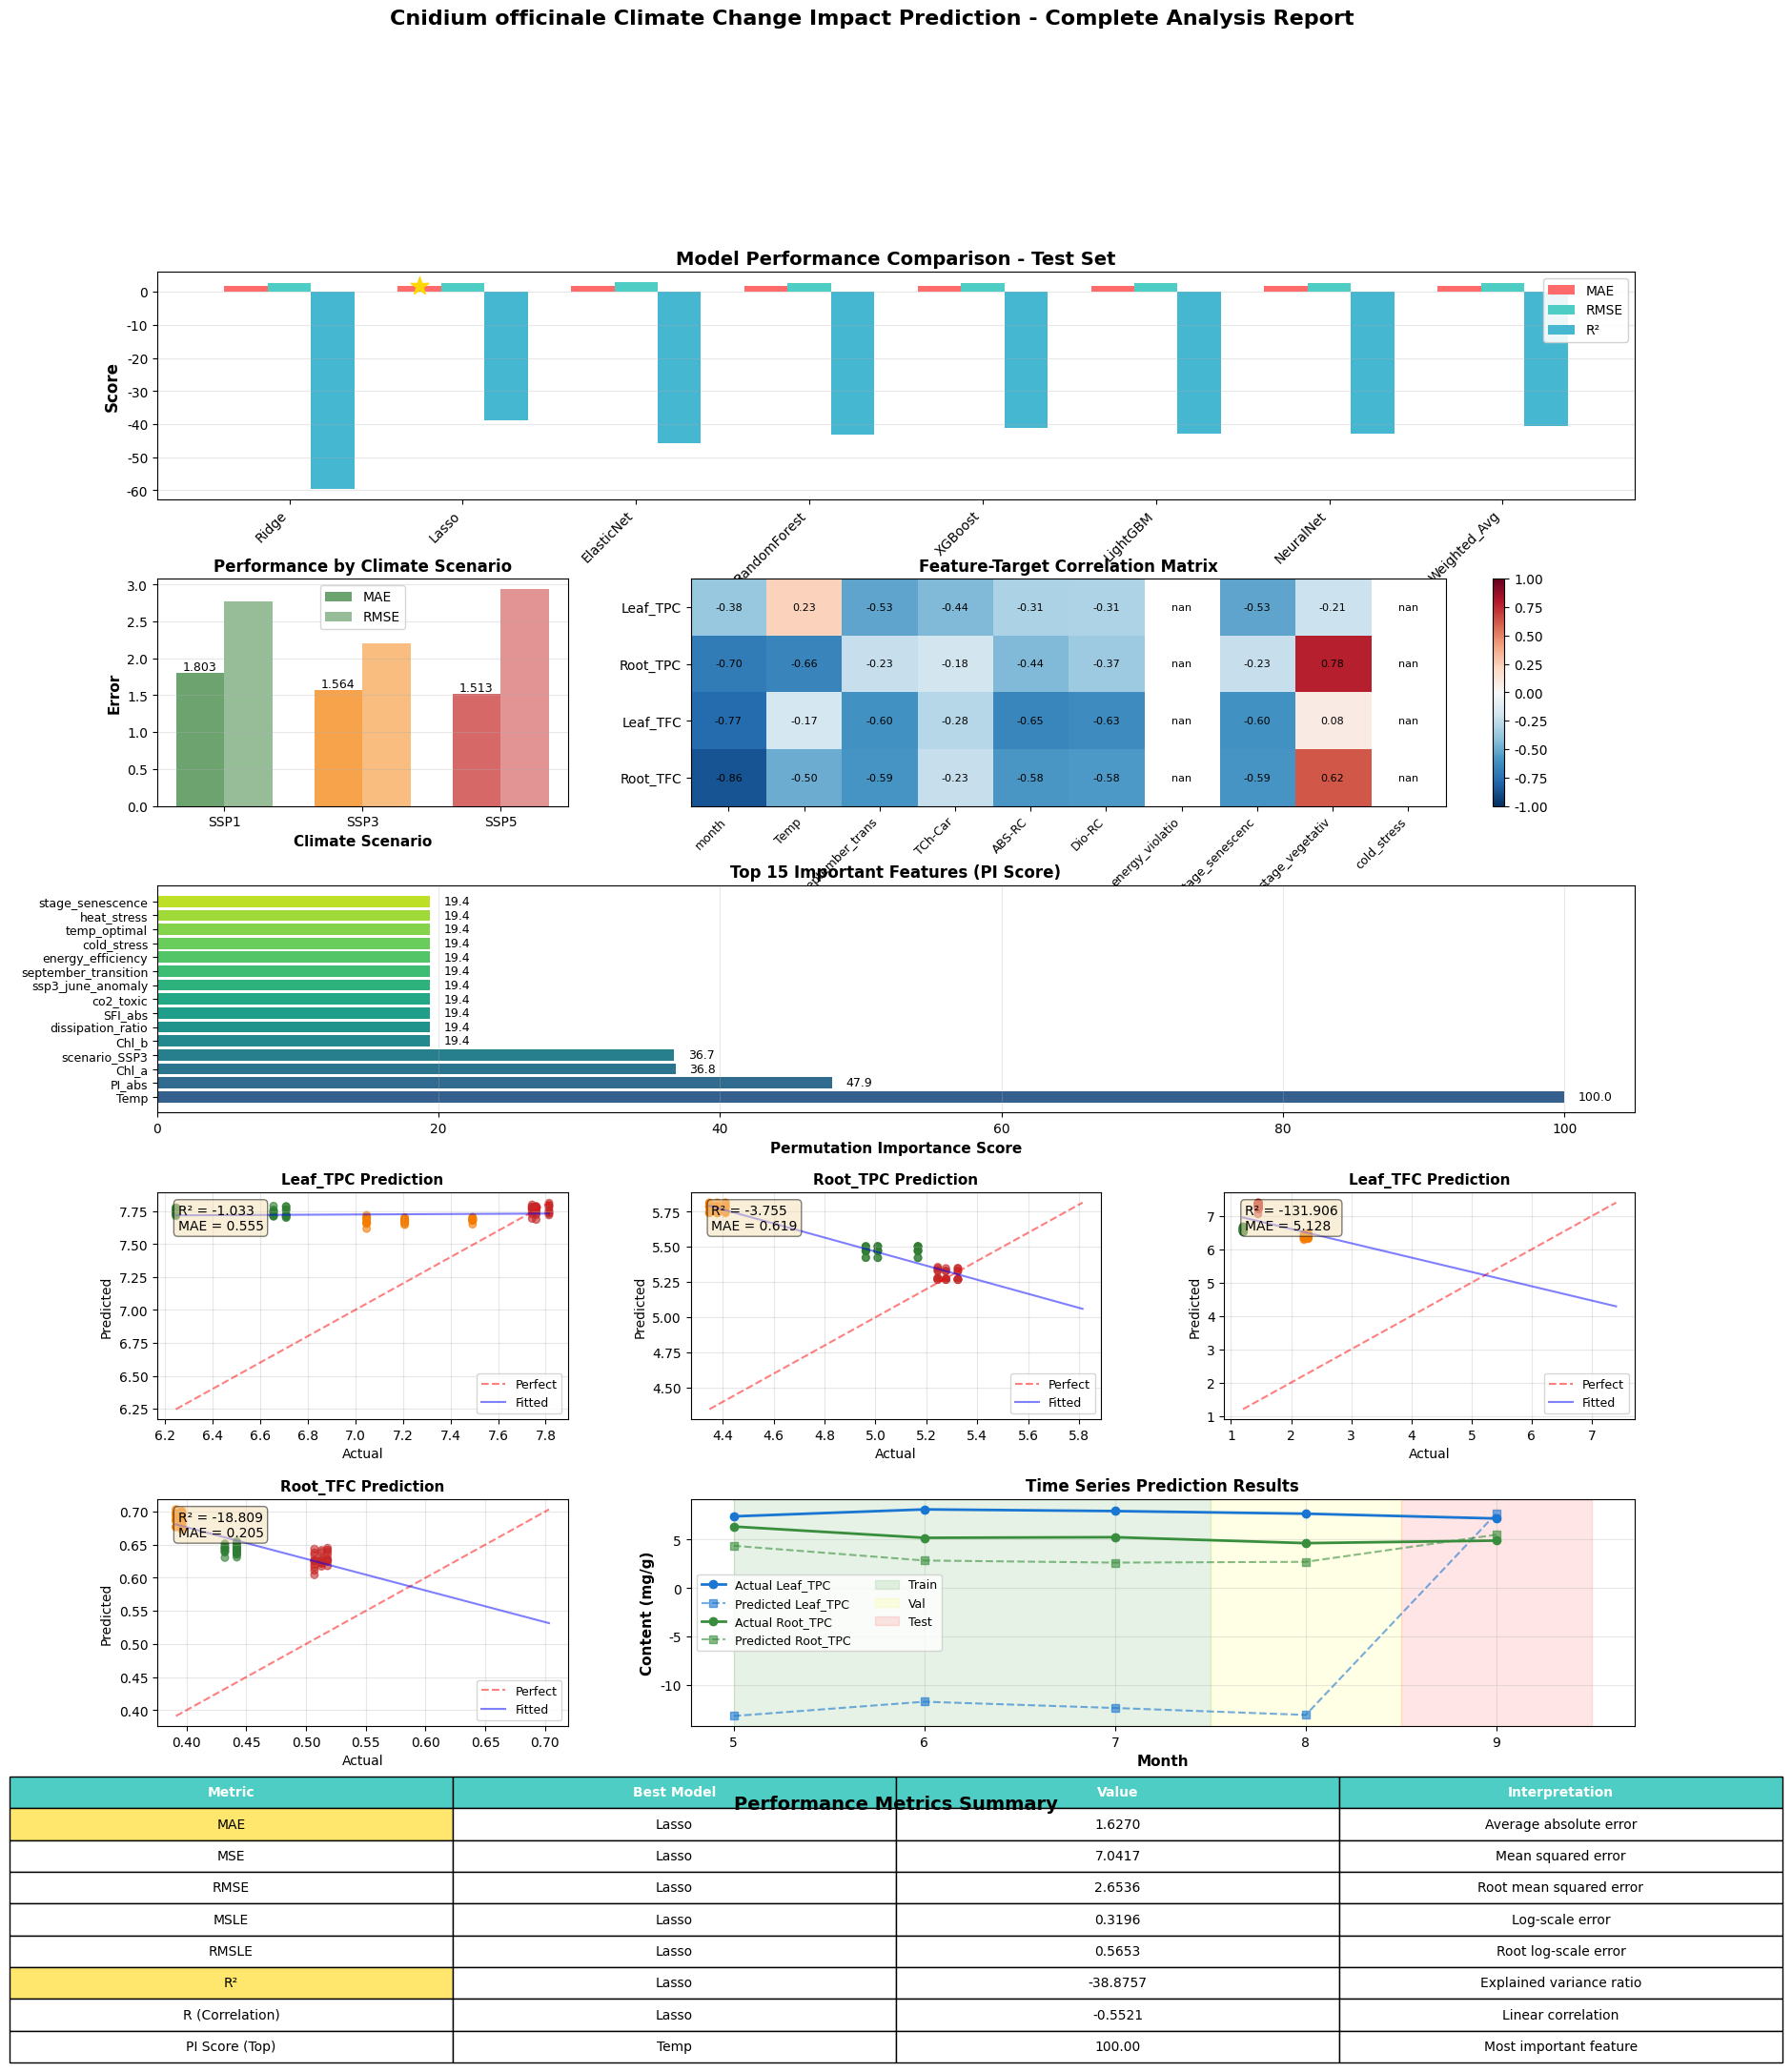

In [98]:
# 그림 설정
fig = plt.figure(figsize=(20, 24))
gs = GridSpec(6, 3, figure=fig, hspace=0.35, wspace=0.3)

# 색상 설정
colors_scenario = {'SSP1': '#2E7D32', 'SSP3': '#F57C00', 'SSP5': '#C62828'}
colors_target = {'Leaf_TPC': '#1976D2', 'Root_TPC': '#388E3C', 
                'Leaf_TFC': '#7B1FA2', 'Root_TFC': '#F57C00'}

# 모델 성능 비교 (막대 그래프)
ax1 = fig.add_subplot(gs[0, :])

model_names = list(results.keys())
mae_scores = [results[m]['test']['MAE'] for m in model_names]
rmse_scores = [results[m]['test']['RMSE'] for m in model_names]
r2_scores = [results[m]['test']['R2'] for m in model_names]

x = np.arange(len(model_names))
width = 0.25

bars1 = ax1.bar(x - width, mae_scores, width, label='MAE', color='#FF6B6B')
bars2 = ax1.bar(x, rmse_scores, width, label='RMSE', color='#4ECDC4')
bars3 = ax1.bar(x + width, r2_scores, width, label='R²', color='#45B7D1')

ax1.set_xlabel('Models', fontsize=12, fontweight='bold')
ax1.set_ylabel('Score', fontsize=12, fontweight='bold')
ax1.set_title('Model Performance Comparison - Test Set', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(model_names, rotation=45, ha='right')
ax1.legend(loc='upper right', framealpha=0.9)
ax1.grid(axis='y', alpha=0.3)

# 최고 성능 모델 표시
best_idx = mae_scores.index(min(mae_scores))
ax1.scatter(best_idx - width, mae_scores[best_idx], 
           s=200, marker='*', color='gold', zorder=5)

# 2. 시나리오별 예측 성능
ax2 = fig.add_subplot(gs[1, 0])

scenarios = list(scenario_results.keys())
scenario_mae = [scenario_results[s]['MAE'] for s in scenarios]
scenario_rmse = [scenario_results[s]['RMSE'] for s in scenarios]

x = np.arange(len(scenarios))
width = 0.35

bars1 = ax2.bar(x - width/2, scenario_mae, width, label='MAE',
               color=[colors_scenario[s] for s in scenarios], alpha=0.7)
bars2 = ax2.bar(x + width/2, scenario_rmse, width, label='RMSE',
               color=[colors_scenario[s] for s in scenarios], alpha=0.5)

ax2.set_xlabel('Climate Scenario', fontsize=11, fontweight='bold')
ax2.set_ylabel('Error', fontsize=11, fontweight='bold')
ax2.set_title('Performance by Climate Scenario', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(scenarios)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# 값 표시
for bar in bars1:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}', ha='center', va='bottom', fontsize=9)

# 3. 특성-타겟 상관관계 히트맵
ax3 = fig.add_subplot(gs[1, 1:])

# 상위 중요 특성만 선택
top_features_for_heatmap = []
for target in target_names:
    corrs = np.abs(correlation_matrix[:, target_names.index(target)])
    top_idx = np.argsort(corrs)[-5:]
    top_features_for_heatmap.extend(top_idx)
top_features_for_heatmap = list(set(top_features_for_heatmap))[:10]

corr_subset = correlation_matrix[top_features_for_heatmap, :]

im = ax3.imshow(corr_subset.T, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)

ax3.set_xticks(np.arange(len(top_features_for_heatmap)))
ax3.set_yticks(np.arange(len(target_names)))
ax3.set_xticklabels([feature_names[idx][:15] for idx in top_features_for_heatmap], 
                    rotation=45, ha='right', fontsize=9)
ax3.set_yticklabels(target_names, fontsize=10)
ax3.set_title('Feature-Target Correlation Matrix', fontsize=12, fontweight='bold')

# 값 표시
for i in range(len(top_features_for_heatmap)):
    for j in range(len(target_names)):
        text = ax3.text(i, j, f'{corr_subset[i, j]:.2f}',
                       ha="center", va="center", color="black", fontsize=8)

plt.colorbar(im, ax=ax3)

# 4. Permutation Importance (TOP 15)
ax4 = fig.add_subplot(gs[2, :])

top_15_features = [f[0] for f in top_features_list]
top_15_scores = [f[1] for f in top_features_list]

y_pos = np.arange(len(top_15_features))
colors_pi = plt.cm.viridis(np.linspace(0.3, 0.9, len(top_15_features)))

bars = ax4.barh(y_pos, top_15_scores, color=colors_pi)
ax4.set_yticks(y_pos)
ax4.set_yticklabels(top_15_features, fontsize=9)
ax4.set_xlabel('Permutation Importance Score', fontsize=11, fontweight='bold')
ax4.set_title('Top 15 Important Features (PI Score)', fontsize=12, fontweight='bold')
ax4.grid(axis='x', alpha=0.3)

# 값 표시
for bar, score in zip(bars, top_15_scores):
    ax4.text(score + 1, bar.get_y() + bar.get_height()/2,
            f'{score:.1f}', va='center', fontsize=9)

#5. 예측 vs 실제값 산점도 (4개 타겟)
for idx, target in enumerate(target_names):
    ax = fig.add_subplot(gs[3, idx] if idx < 3 else gs[4, 0])
    
    # 실제 및 예측값
    y_true_target = y_test[:, idx]
    y_pred_target = y_pred_final[:, idx]
    
    # 시나리오별 색상
    scenario_colors = [colors_scenario[s] for s in scenario_test]
    
    ax.scatter(y_true_target, y_pred_target, alpha=0.6, c=scenario_colors, s=30)
    
    # 완벽한 예측선
    min_val = min(y_true_target.min(), y_pred_target.min())
    max_val = max(y_true_target.max(), y_pred_target.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.5, label='Perfect')
    
    # 회귀선
    z = np.polyfit(y_true_target, y_pred_target, 1)
    p = np.poly1d(z)
    x_line = np.linspace(min_val, max_val, 100)
    ax.plot(x_line, p(x_line), "b-", alpha=0.5, label='Fitted')
    
    # R² 값 표시
    r2 = r2_score(y_true_target, y_pred_target)
    mae = mean_absolute_error(y_true_target, y_pred_target)
    ax.text(0.05, 0.95, f'R² = {r2:.3f}\nMAE = {mae:.3f}', 
           transform=ax.transAxes, fontsize=10, verticalalignment='top',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    ax.set_xlabel('Actual', fontsize=10)
    ax.set_ylabel('Predicted', fontsize=10)
    ax.set_title(f'{target} Prediction', fontsize=11, fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(alpha=0.3)

# 6. 시계열 예측 결과
ax6 = fig.add_subplot(gs[4, 1:])

# 월별 실제 vs 예측 평균값
months_unique = np.sort(np.unique(months))
mean_actual = np.zeros((len(months_unique), len(target_names)))
mean_pred = np.zeros((len(months_unique), len(target_names)))

for i, month in enumerate(months_unique):
    month_mask = months == month
    mean_actual[i] = y_targets.values[month_mask].mean(axis=0)
    
    # 해당 월의 예측값 계산
    if month <= 7:  # Train
        X_month = X_tree.values[month_mask]
        y_pred_month = best_model.predict(X_month)
    elif month == 8:  # Val
        X_month = X_tree.values[month_mask]
        y_pred_month = best_model.predict(X_month)
    else:  # Test
        y_pred_month = y_pred_final
    
    mean_pred[i] = y_pred_month.mean(axis=0)

# 두 개 타겟만 시각화 (Leaf_TPC, Root_TPC)
for i, target in enumerate(['Leaf_TPC', 'Root_TPC']):
    target_idx = target_names.index(target)
    ax6.plot(months_unique, mean_actual[:, target_idx], 'o-', 
            label=f'Actual {target}', color=colors_target[target], linewidth=2)
    ax6.plot(months_unique, mean_pred[:, target_idx], 's--', 
            label=f'Predicted {target}', color=colors_target[target], alpha=0.6)

# 데이터 분할 구간 표시
ax6.axvspan(5, 7.5, alpha=0.1, color='green', label='Train')
ax6.axvspan(7.5, 8.5, alpha=0.1, color='yellow', label='Val')
ax6.axvspan(8.5, 9.5, alpha=0.1, color='red', label='Test')

ax6.set_xlabel('Month', fontsize=11, fontweight='bold')
ax6.set_ylabel('Content (mg/g)', fontsize=11, fontweight='bold')
ax6.set_title('Time Series Prediction Results', fontsize=12, fontweight='bold')
ax6.legend(loc='best', ncol=2, fontsize=9)
ax6.grid(alpha=0.3)
ax6.set_xticks(months_unique)

# 7. 평가 지표 요약 테이블
ax7 = fig.add_subplot(gs[5, :])
ax7.axis('off')

# 최종 성능 지표
final_metrics = results[final_model_name]['test'] if final_model_name in results else stack_metrics

# 테이블 데이터
table_data = [
    ['Metric', 'Best Model', 'Value', 'Interpretation'],
    ['MAE', final_model_name, f"{final_metrics['MAE']:.4f}", 'Average absolute error'],
    ['MSE', final_model_name, f"{final_metrics['MSE']:.4f}", 'Mean squared error'],
    ['RMSE', final_model_name, f"{final_metrics['RMSE']:.4f}", 'Root mean squared error'],
    ['MSLE', final_model_name, f"{final_metrics['MSLE']:.4f}", 'Log-scale error'],
    ['RMSLE', final_model_name, f"{final_metrics['RMSLE']:.4f}", 'Root log-scale error'],
    ['R²', final_model_name, f"{final_metrics['R2']:.4f}", 'Explained variance ratio'],
    ['R (Correlation)', final_model_name, f"{final_metrics['R']:.4f}", 'Linear correlation'],
    ['PI Score (Top)', top_features_list[0][0][:20], f"{top_features_list[0][1]:.2f}", 'Most important feature']
]

# 테이블 생성
table = ax7.table(cellText=table_data, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 2)

# 헤더 스타일
for i in range(len(table_data[0])):
    table[(0, i)].set_facecolor('#4ECDC4')
    table[(0, i)].set_text_props(weight='bold', color='white')

# 최고 성능 행 강조
table[(1, 0)].set_facecolor('#FFE66D')
table[(6, 0)].set_facecolor('#FFE66D')

ax7.set_title('Performance Metrics Summary', fontsize=14, fontweight='bold', y=0.95)

# 전체 제목
fig.suptitle('Cnidium officinale Climate Change Impact Prediction - Complete Analysis Report', 
            fontsize=16, fontweight='bold', y=0.995)